# Ejercicio de clase — Camino óptimo en un grid 15x15

**Juan David Sierra Orozco**
Inteligencia Artificial (SI3003), EAFIT

## Enunciado

Construir un grid de 15x15 con 5 obstáculos, un estado inicial y un estado final. Trazar el mejor camino entre el inicio y el fin usando:

1. **Método de valores** (Value Iteration)
2. **Política de dirección** (Policy Iteration)
3. **Aprendizaje por refuerzo** (Q-Learning), mostrando el avance a lo largo de las iteraciones

## Cómo está organizado

El mismo mundo se resuelve de tres maneras distintas, y la gracia está en comparar qué necesita cada una:

| Método | ¿Conoce el modelo? | Qué calcula |
|---|---|---|
| Value Iteration | Sí, usa $T(s,a,s')$ | $V^*$ directamente, con el `max` dentro de Bellman |
| Policy Iteration | Sí, usa $T(s,a,s')$ | Alterna evaluar $V^\pi$ y mejorar $\pi$ |
| Q-Learning | **No**, solo experiencia $(s,a,r,s')$ | $Q(s,a)$ a partir de episodios |

Los dos primeros son planificación: se resuelven en el escritorio porque el modelo ya se conoce. El tercero es aprendizaje: el agente descubre el mundo caminándolo.

---

## 1. El mundo

Grid de 15x15 con 5 obstáculos. El inicio está en la esquina superior izquierda y la meta en la inferior derecha, de modo que los obstáculos quedan sobre la diagonal natural entre ambos.

**Convención** (la misma de los notebooks del curso):

$$s=(row,col) \qquad a=(\Delta row,\Delta col) \qquad T(s,a,s')=P(s'\mid s,a) \qquad R(s)$$

**Dinámica.** El movimiento es estocástico, como en el GridWorld de clase: la acción se ejecuta con probabilidad 0.8, y con 0.1 el agente se desvía a cada lado. Si el movimiento sale del grid o choca contra un obstáculo, el agente se queda donde está.

Sin ese ruido el ejercicio sería un simple problema de caminos más cortos. Con ruido, los obstáculos importan de verdad, porque acercarse a uno implica el riesgo de quedarse trabado contra él.

**Recompensas.** Meta `+100` y terminal, cualquier otro paso `-1`. El costo por paso es lo que empuja al agente a buscar el camino corto.

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# Acciones
UP, DOWN, LEFT, RIGHT = (-1, 0), (1, 0), (0, -1), (0, 1)
NOMBRES = {UP: "arriba", DOWN: "abajo", LEFT: "izquierda", RIGHT: "derecha"}
FLECHAS = {UP: "^", DOWN: "v", LEFT: "<", RIGHT: ">"}


class GridWorld15:
    """Grid 15x15 con 5 obstáculos, inicio en (0,0) y meta en (14,14)."""

    def __init__(self, p_intended=0.8, living_reward=-1.0,
                 goal_reward=100.0, gamma=0.95):
        self.height = 15
        self.width = 15

        self.start = (0, 0)
        self.goal = (14, 14)

        # Los 5 obstáculos, ubicados sobre la diagonal que une inicio y meta
        self.obstacles = {(3, 3), (5, 7), (7, 7), (9, 5), (11, 11)}

        self.living_reward = living_reward
        self.goal_reward = goal_reward
        self.gamma = gamma

        self.p_intended = p_intended
        self.p_perpendicular = (1.0 - p_intended) / 2.0

        self.actions = [UP, DOWN, LEFT, RIGHT]

    def is_valid_state(self, state):
        row, col = state
        if not (0 <= row < self.height and 0 <= col < self.width):
            return False
        return state not in self.obstacles

    def states(self):
        return [(r, c) for r in range(self.height) for c in range(self.width)
                if self.is_valid_state((r, c))]

    def is_terminal(self, state):
        return state == self.goal

    def get_reward(self, state):
        # R(s): la meta paga, cualquier otro estado cuesta
        return self.goal_reward if state == self.goal else self.living_reward

    def get_transition_probs(self, state, action):
        """T(s,a,s') como lista [(next_state, probability), ...]."""
        if self.is_terminal(state):
            return [(state, 1.0)]

        perp1 = (action[1], action[0])
        perp2 = (-action[1], -action[0])

        outcomes = [
            (action, self.p_intended),
            (perp1, self.p_perpendicular),
            (perp2, self.p_perpendicular),
        ]

        transitions = []
        for move, prob in outcomes:
            nxt = (state[0] + move[0], state[1] + move[1])
            if not self.is_valid_state(nxt):
                nxt = state          # choca con obstáculo o borde: se queda
            transitions.append((nxt, prob))
        return transitions

    def step(self, state, action, rng):
        """Muestrea una transición real. Lo usa Q-Learning."""
        u = rng.random()
        acumulado = 0.0
        for nxt, prob in self.get_transition_probs(state, action):
            acumulado += prob
            if u <= acumulado:
                break
        return nxt, self.get_reward(nxt), self.is_terminal(nxt)


grid = GridWorld15()
print("Estados transitables:", len(grid.states()), "de", grid.height * grid.width)
print("Obstáculos:", sorted(grid.obstacles))
print("Inicio:", grid.start, " Meta:", grid.goal)

# Validación: toda distribución T(s,a,.) debe sumar 1
for s in grid.states():
    for a in grid.actions:
        assert abs(sum(p for _, p in grid.get_transition_probs(s, a)) - 1.0) < 1e-12
print("Todas las distribuciones de transición suman 1.")

Estados transitables: 220 de 225
Obstáculos: [(3, 3), (5, 7), (7, 7), (9, 5), (11, 11)]
Inicio: (0, 0)  Meta: (14, 14)
Todas las distribuciones de transición suman 1.


### Función de dibujo

Una sola función para todo el notebook: pinta el grid y, opcionalmente, superpone los valores como mapa de calor, la política como flechas, y un camino recorrido.

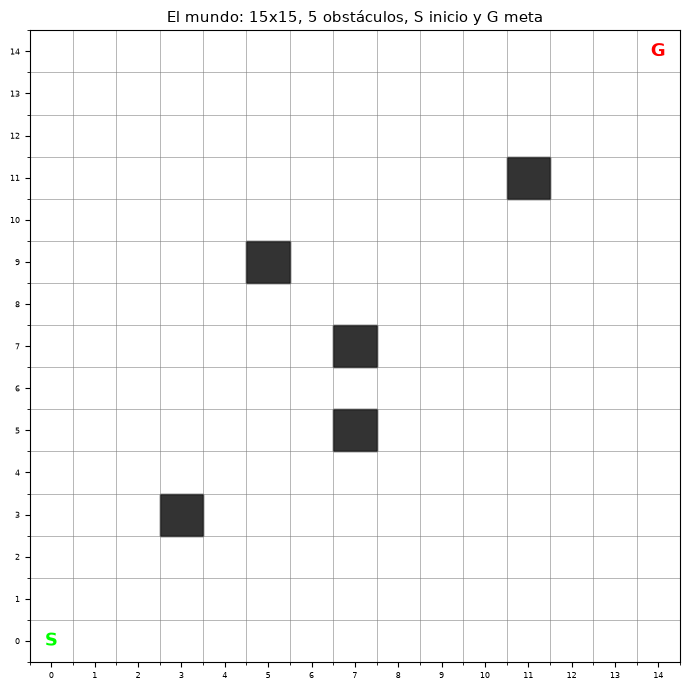

In [2]:
def dibujar(grid, V=None, policy=None, path=None, titulo="", ax=None, mostrar_valores=False):
    creado = False
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 7))
        creado = True

    H, W = grid.height, grid.width

    # Mapa de calor de los valores
    if V is not None:
        M = np.full((H, W), np.nan)
        for (r, c), v in V.items():
            M[r, c] = v
        ax.imshow(M, cmap="viridis", origin="upper")

    # Obstáculos
    for (r, c) in grid.obstacles:
        ax.add_patch(Rectangle((c - 0.5, r - 0.5), 1, 1,
                               facecolor="#333333", edgecolor="black"))

    # Flechas de la política
    if policy is not None:
        for (r, c), a in policy.items():
            if grid.is_terminal((r, c)):
                continue
            dr, dc = a
            ax.arrow(c, r, dc * 0.3, dr * 0.3, head_width=0.22,
                     head_length=0.18, fc="white", ec="black", linewidth=0.6)

    # Camino recorrido
    if path is not None:
        ys = [r for r, c in path]
        xs = [c for r, c in path]
        ax.plot(xs, ys, color="red", linewidth=2.5, alpha=0.9, zorder=5)
        ax.scatter(xs, ys, color="red", s=14, zorder=6)

    # Valores numéricos (solo si se piden, en 15x15 quedan apretados)
    if mostrar_valores and V is not None:
        for (r, c), v in V.items():
            ax.text(c, r, f"{v:.0f}", ha="center", va="center",
                    fontsize=5, color="white")

    sr, sc = grid.start
    gr, gc = grid.goal
    ax.text(sc, sr, "S", ha="center", va="center", fontsize=13,
            fontweight="bold", color="lime", zorder=7)
    ax.text(gc, gr, "G", ha="center", va="center", fontsize=13,
            fontweight="bold", color="red", zorder=7)

    ax.set_xticks(range(W)); ax.set_yticks(range(H))
    ax.set_xticklabels(range(W), fontsize=6); ax.set_yticklabels(range(H), fontsize=6)
    ax.set_xticks(np.arange(-0.5, W, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, H, 1), minor=True)
    ax.grid(which="minor", color="gray", linewidth=0.4)
    ax.set_title(titulo, fontsize=11)
    if creado:
        plt.tight_layout()
    return ax


dibujar(grid, titulo="El mundo: 15x15, 5 obstáculos, S inicio y G meta")
plt.show()

---

## 2. Método de valores (Value Iteration)

Aplica la ecuación de Bellman de optimalidad hasta que los valores dejan de cambiar:

$$V_{k+1}(s)=R(s)+\gamma\max_a\sum_{s'}T(s,a,s')V_k(s')$$

El criterio de parada es $\max_s|V_{k+1}(s)-V_k(s)|<\theta$. Guardamos ese máximo en cada iteración para poder graficar la convergencia.

In [3]:
def expected_next_value(grid, state, action, V):
    """Sum_{s'} T(s,a,s') V(s')"""
    return sum(prob * V[nxt] for nxt, prob in grid.get_transition_probs(state, action))


def value_iteration(grid, threshold=1e-4, max_iter=10_000):
    V = {s: 0.0 for s in grid.states()}
    deltas = []
    instantaneas = {}

    for iteracion in range(max_iter):
        V_new = V.copy()
        mayor_cambio = 0.0

        for s in grid.states():
            if grid.is_terminal(s):
                V_new[s] = grid.get_reward(s)
            else:
                mejor = max(expected_next_value(grid, s, a, V) for a in grid.actions)
                V_new[s] = grid.get_reward(s) + grid.gamma * mejor
            mayor_cambio = max(mayor_cambio, abs(V_new[s] - V[s]))

        V = V_new
        deltas.append(mayor_cambio)

        # Guardamos algunas iteraciones para ver cómo se propaga el valor
        if iteracion + 1 in (1, 2, 5, 15, 30):
            instantaneas[iteracion + 1] = V.copy()

        if mayor_cambio < threshold:
            break

    return V, iteracion + 1, deltas, instantaneas


def extract_policy(grid, V):
    """pi*(s) = argmax_a Sum_{s'} T(s,a,s') V(s')"""
    return {s: max(grid.actions, key=lambda a: expected_next_value(grid, s, a, V))
            for s in grid.states() if not grid.is_terminal(s)}


V_vi, n_vi, deltas_vi, instantaneas = value_iteration(grid)
pi_vi = extract_policy(grid, V_vi)

print(f"Value Iteration convergió en {n_vi} iteraciones")
print(f"V*(inicio) = {V_vi[grid.start]:.3f}")
print(f"V*(vecino de la meta) = {V_vi[(13, 14)]:.3f}")

Value Iteration convergió en 58 iteraciones
V*(inicio) = 1.467
V*(vecino de la meta) = 91.788


### Las iteraciones de Value Iteration

Así se propaga el valor desde la meta hacia el resto del grid. En la iteración 1 solo la meta tiene información; con cada barrido esa información se corre una celda más.

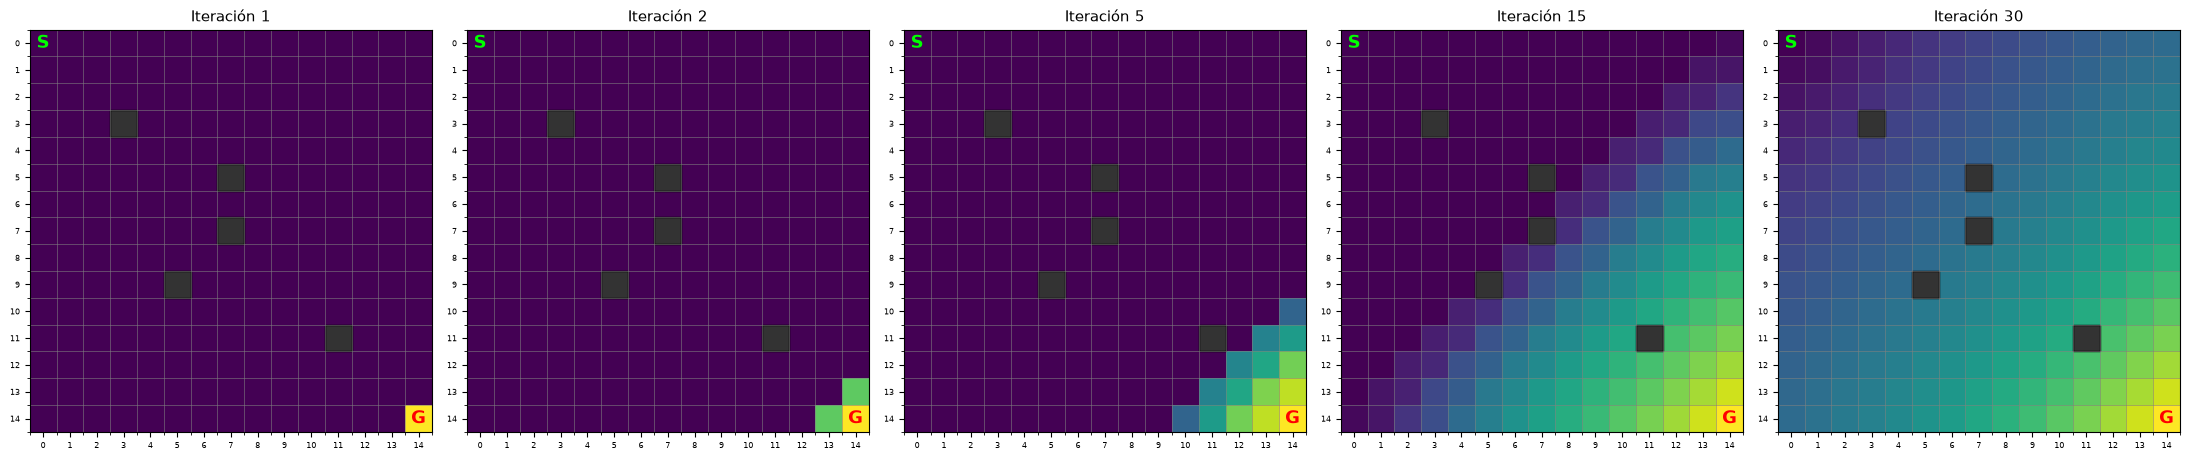

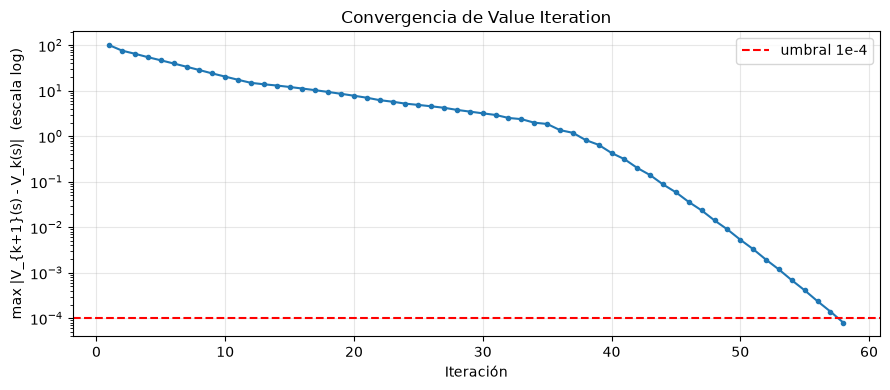

Primeras iteraciones:
   iteración   1   cambio máximo = 100.0000
   iteración   2   cambio máximo = 75.8100
   iteración   3   cambio máximo = 64.7273
   iteración   4   cambio máximo = 54.5633
   iteración   5   cambio máximo = 46.5702
Últimas iteraciones:
   iteración  56   cambio máximo = 0.000237
   iteración  57   cambio máximo = 0.000140
   iteración  58   cambio máximo = 0.000080


In [4]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4.6))
for ax, k in zip(axes, sorted(instantaneas)):
    dibujar(grid, V=instantaneas[k], titulo=f"Iteración {k}", ax=ax)
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 4))
plt.semilogy(range(1, len(deltas_vi) + 1), deltas_vi, marker="o", markersize=3)
plt.axhline(1e-4, color="red", linestyle="--", label="umbral 1e-4")
plt.xlabel("Iteración")
plt.ylabel("max |V_{k+1}(s) - V_k(s)|  (escala log)")
plt.title("Convergencia de Value Iteration")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.show()

print("Primeras iteraciones:")
for k in range(min(5, len(deltas_vi))):
    print(f"   iteración {k+1:3d}   cambio máximo = {deltas_vi[k]:.4f}")
print("Últimas iteraciones:")
for k in range(max(0, len(deltas_vi) - 3), len(deltas_vi)):
    print(f"   iteración {k+1:3d}   cambio máximo = {deltas_vi[k]:.6f}")

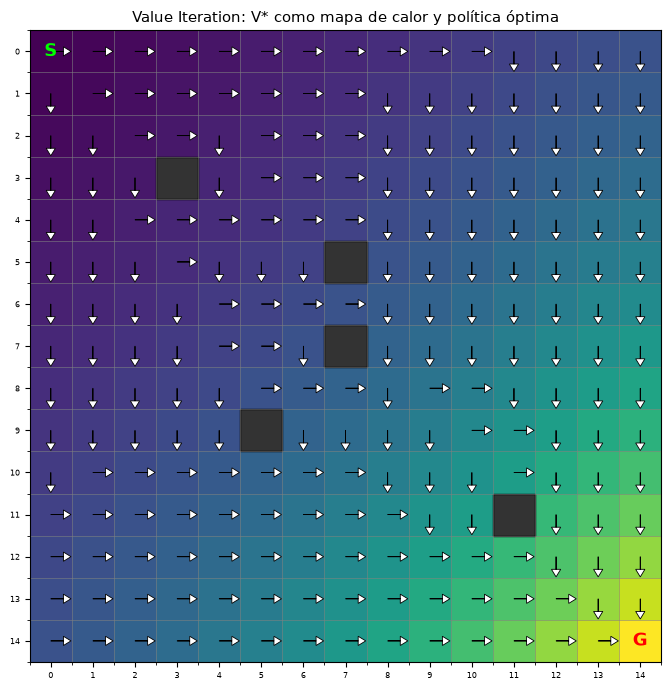

In [5]:
dibujar(grid, V=V_vi, policy=pi_vi,
        titulo="Value Iteration: V* como mapa de calor y política óptima")
plt.show()

---

## 3. Política de dirección (Policy Iteration)

En vez de mezclar evaluación y mejora en un solo `max`, las separa:

**Evaluación**, sin `max` porque la política ya eligió la acción:

$$V_{k+1}^{\pi}(s)=R(s)+\gamma\sum_{s'}T(s,\pi(s),s')V_k^{\pi}(s')$$

**Mejora**:

$$\pi_{\text{new}}(s)=\arg\max_a\sum_{s'}T(s,a,s')V^{\pi}(s')$$

Se repite hasta que ninguna acción cambie. Registramos cada iteración para ver cuántos barridos de evaluación cuesta y cuántas acciones se modifican.

In [6]:
def policy_evaluation(grid, policy, threshold=1e-4, max_iter=10_000):
    V = {s: 0.0 for s in grid.states()}
    for barrido in range(max_iter):
        V_new = V.copy()
        mayor_cambio = 0.0
        for s in grid.states():
            if grid.is_terminal(s):
                V_new[s] = grid.get_reward(s)
            else:
                V_new[s] = (grid.get_reward(s)
                            + grid.gamma * expected_next_value(grid, s, policy[s], V))
            mayor_cambio = max(mayor_cambio, abs(V_new[s] - V[s]))
        V = V_new
        if mayor_cambio < threshold:
            break
    return V, barrido + 1


def policy_improvement(grid, V):
    return extract_policy(grid, V)


def policy_iteration(grid, threshold=1e-4, max_iter=100):
    # Política inicial arbitraria: todos hacia arriba
    policy = {s: grid.actions[0] for s in grid.states() if not grid.is_terminal(s)}
    historia = []
    instantaneas = {}

    for iteracion in range(max_iter):
        V, barridos = policy_evaluation(grid, policy, threshold)
        nueva = policy_improvement(grid, V)
        cambios = sum(1 for s in nueva if nueva[s] != policy[s])

        historia.append({"iteracion": iteracion + 1,
                         "barridos_evaluacion": barridos,
                         "acciones_cambiadas": cambios})
        policy = nueva
        if iteracion + 1 in (1, 2, 5, 10):
            instantaneas[iteracion + 1] = (dict(policy), V.copy())
        if cambios == 0:
            break

    return policy, V, historia, instantaneas


pi_pi, V_pi, historia_pi, instantaneas_pi = policy_iteration(grid)

print(f"{'iteración':>10} | {'barridos de evaluación':>22} | {'acciones cambiadas':>19}")
print("-" * 58)
for h in historia_pi:
    print(f"{h['iteracion']:>10} | {h['barridos_evaluacion']:>22} | {h['acciones_cambiadas']:>19}")

total = sum(h["barridos_evaluacion"] for h in historia_pi)
print(f"\nPolicy Iteration: {len(historia_pi)} iteraciones de política, {total} barridos en total")
print(f"Value Iteration:  {n_vi} iteraciones")

 iteración | barridos de evaluación |  acciones cambiadas
----------------------------------------------------------
         1 |                    181 |                  29
         2 |                    181 |                  15
         3 |                    181 |                  29
         4 |                    181 |                  25
         5 |                    181 |                  26
         6 |                    181 |                  20
         7 |                    181 |                  17
         8 |                    181 |                  16
         9 |                    181 |                  16
        10 |                    181 |                  17
        11 |                    181 |                  19
        12 |                    181 |                  19
        13 |                    181 |                  18
        14 |                    181 |                  20
        15 |                     58 |                  14
        16 | 

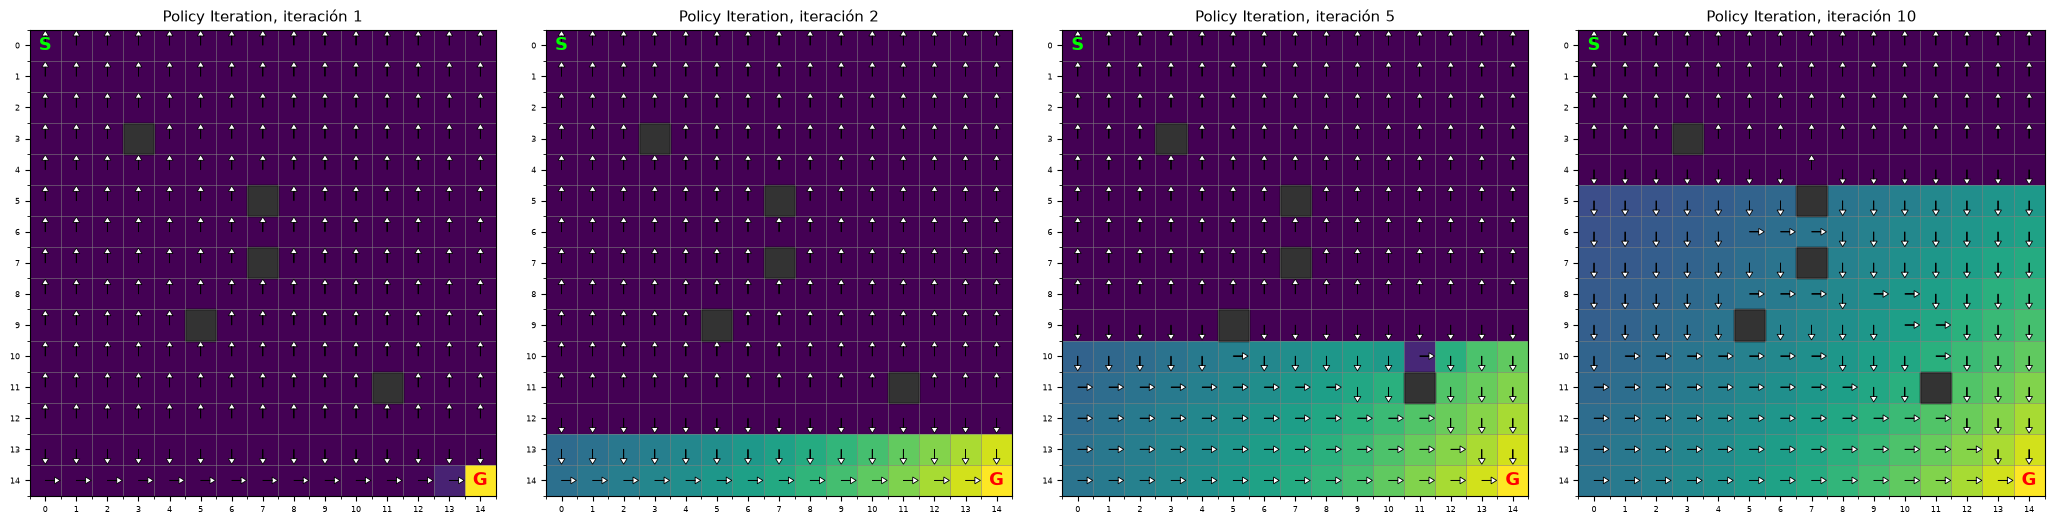

In [7]:
fig, axes = plt.subplots(1, len(instantaneas_pi), figsize=(5.2 * len(instantaneas_pi), 5))
for ax, k in zip(np.atleast_1d(axes), sorted(instantaneas_pi)):
    pol, Vk = instantaneas_pi[k]
    dibujar(grid, V=Vk, policy=pol, titulo=f"Policy Iteration, iteración {k}", ax=ax)
plt.tight_layout()
plt.show()

### Los dos métodos coinciden

Si ambos están bien implementados deben llegar exactamente a la misma política.

In [8]:
iguales = (pi_vi == pi_pi)
distintos = [s for s in pi_vi if pi_vi[s] != pi_pi[s]]

print("¿Misma política?", iguales)
print("Estados con acción distinta:", len(distintos))

max_dif = max(abs(V_vi[s] - V_pi[s]) for s in grid.states())
print(f"Diferencia máxima entre V* y V^pi: {max_dif:.6f}")

assert iguales, "Los dos métodos deberían coincidir"
print("\nAmbos métodos encontraron la misma política óptima.")

¿Misma política? True
Estados con acción distinta: 0
Diferencia máxima entre V* y V^pi: 0.000000

Ambos métodos encontraron la misma política óptima.


### El mejor camino entre inicio y fin

Con la política ya calculada, seguimos las flechas desde el inicio. Se muestran dos cosas distintas: la ruta que el agente *intenta* recorrer (sin ruido) y una ejecución real con la dinámica estocástica.

Camino intencionado: 28 pasos
[(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 7), (0, 8), (0, 9), (0, 10), (0, 11), (1, 11), (2, 11), (3, 11), (4, 11), (5, 11), (6, 11), (7, 11), (8, 11), (9, 11), (9, 12), (10, 12), (11, 12), (12, 12), (13, 12), (13, 13), (14, 13), (14, 14)]

Episodio real: 31 pasos, recompensa 70


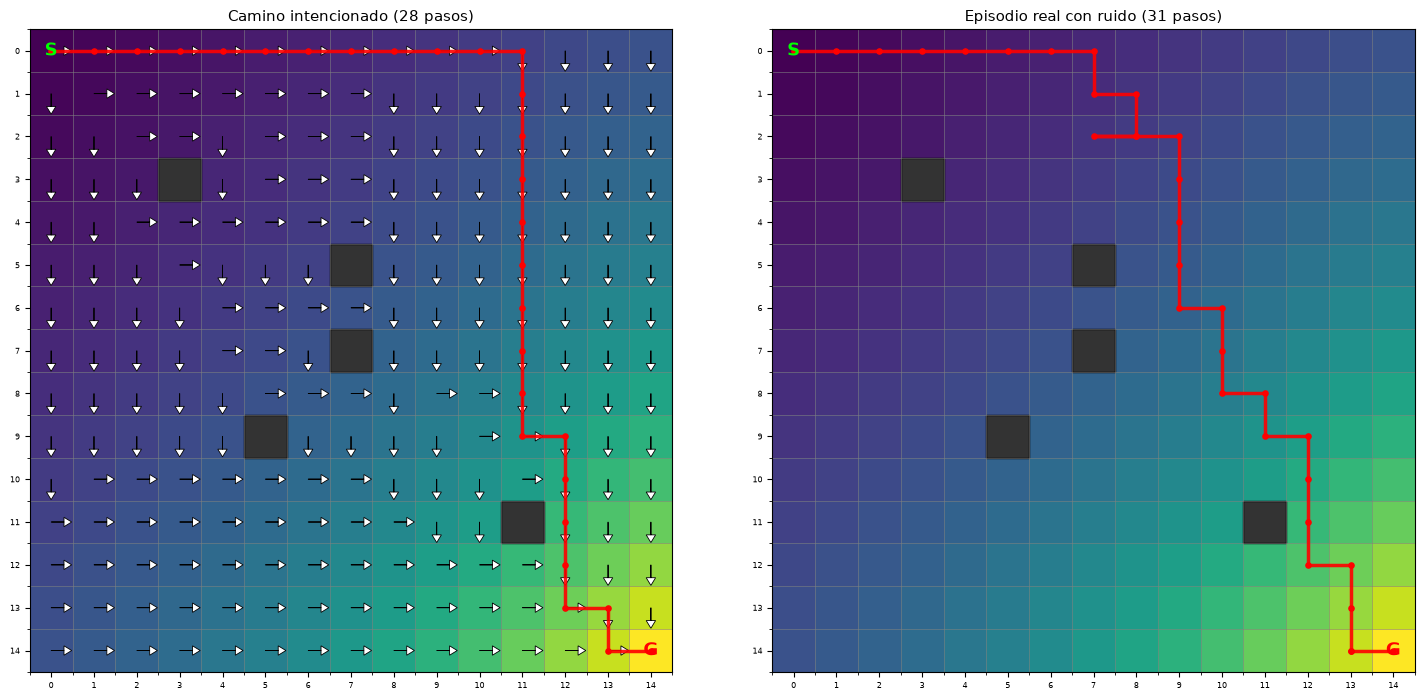

In [9]:
def camino_intencionado(grid, policy, max_steps=200):
    """Ruta ignorando el ruido: sirve para leer la política."""
    s = grid.start
    path = [s]
    for _ in range(max_steps):
        if grid.is_terminal(s):
            break
        a = policy[s]
        nxt = (s[0] + a[0], s[1] + a[1])
        if not grid.is_valid_state(nxt):
            nxt = s
        if nxt == s:
            break
        s = nxt
        path.append(s)
    return path


def episodio_real(grid, policy, seed=0, max_steps=300):
    """Ejecución con la dinámica estocástica real."""
    rng = random.Random(seed)
    s = grid.start
    path = [s]
    total = 0.0
    for _ in range(max_steps):
        if grid.is_terminal(s):
            break
        s, r, done = grid.step(s, policy[s], rng)
        path.append(s)
        total += r
    return path, total


ruta = camino_intencionado(grid, pi_vi)
print(f"Camino intencionado: {len(ruta) - 1} pasos")
print(ruta)

path_real, recompensa_real = episodio_real(grid, pi_vi, seed=3)
print(f"\nEpisodio real: {len(path_real) - 1} pasos, recompensa {recompensa_real:.0f}")

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
dibujar(grid, V=V_vi, policy=pi_vi, path=ruta,
        titulo=f"Camino intencionado ({len(ruta)-1} pasos)", ax=axes[0])
dibujar(grid, V=V_vi, path=path_real,
        titulo=f"Episodio real con ruido ({len(path_real)-1} pasos)", ax=axes[1])
plt.tight_layout()
plt.show()

---

## 4. Aprendizaje por refuerzo (Q-Learning)

Hasta acá los dos métodos usaron $T(s,a,s')$, o sea que conocían el mundo de antemano. Q-Learning no: el agente arranca con $Q(s,a)=0$ y solo recibe experiencias $(s,a,r,s')$.

$$Q(s,a)\leftarrow Q(s,a)+\alpha\left[r+\gamma\max_{a'}Q(s',a')-Q(s,a)\right]$$

La diferencia de fondo con la clase anterior: ese $\max_{a'}$ ya no se calcula sobre un modelo conocido sino sobre la propia tabla $Q$, que es una estimación que el agente construye a los golpes. Por eso Q-Learning es **model free**.

**Exploración.** Se usa $\epsilon$-greedy con $\epsilon$ decreciente: al principio el agente se mueve casi al azar porque no sabe nada, y a medida que aprende confía cada vez más en su tabla.

In [10]:
def q_learning(grid, episodes=5000, alpha=0.1, gamma=None,
               epsilon_inicial=1.0, epsilon_final=0.05, epsilon_decay=0.999,
               max_steps=300, seed=1, checkpoints=()):
    gamma = grid.gamma if gamma is None else gamma
    rng = random.Random(seed)

    Q = {s: {a: 0.0 for a in grid.actions} for s in grid.states()}
    epsilon = epsilon_inicial
    historia = []
    instantaneas = {}

    for ep in range(1, episodes + 1):
        s = grid.start
        total = 0.0
        pasos = 0

        for _ in range(max_steps):
            # epsilon-greedy
            if rng.random() < epsilon:
                a = rng.choice(grid.actions)
            else:
                mejor = max(Q[s].values())
                a = rng.choice([x for x in grid.actions if Q[s][x] == mejor])

            nxt, r, done = grid.step(s, a, rng)

            # Actualización de Q-Learning
            futuro = 0.0 if done else max(Q[nxt].values())
            Q[s][a] += alpha * (r + gamma * futuro - Q[s][a])

            s = nxt
            total += r
            pasos += 1
            if done:
                break

        epsilon = max(epsilon_final, epsilon * epsilon_decay)
        historia.append({"episodio": ep, "recompensa": total,
                         "pasos": pasos, "epsilon": epsilon, "llego": done})

        if ep in checkpoints:
            instantaneas[ep] = {st: dict(Q[st]) for st in Q}

    return Q, historia, instantaneas


def politica_greedy(grid, Q):
    return {s: max(grid.actions, key=lambda a: Q[s][a])
            for s in grid.states() if not grid.is_terminal(s)}


CHECKPOINTS = (1, 10, 50, 200, 1000, 2500, 5000)

Q, historia_ql, instantaneas_ql = q_learning(grid, episodes=5000, checkpoints=CHECKPOINTS)
pi_ql = politica_greedy(grid, Q)

print("Entrenamiento terminado:", len(historia_ql), "episodios")
print("Valores aprendidos:", len(Q) * 4)

Entrenamiento terminado: 5000 episodios
Valores aprendidos: 880


### El mecanismo, paso a paso

Antes de mirar las 5000 iteraciones completas, conviene ver una sola. Con la tabla en cero, la primera actualización que recibe recompensa mueve el valor un `alpha` del camino hacia el objetivo.

In [11]:
demo = GridWorld15()
Q_demo = {s: {a: 0.0 for a in demo.actions} for s in demo.states()}

# Tomamos el estado justo encima de la meta y la acción que lleva a ella.
# Usamos el resultado intencionado, que ocurre con probabilidad 0.8.
s = (13, 14)
a = DOWN
nxt = (14, 14)
r = demo.get_reward(nxt)
done = demo.is_terminal(nxt)

antes = Q_demo[s][a]
futuro = 0.0 if done else max(Q_demo[nxt].values())
td_target = r + demo.gamma * futuro
td_error = td_target - antes
Q_demo[s][a] += 0.1 * td_error

print(f"Transición: {s} --{NOMBRES[a]}--> {nxt}")
print(f"  recompensa r      = {r:+.0f}")
print(f"  ¿terminal?        = {done}   (por eso el término futuro vale 0)")
print()
print(f"  Q(s,a) antes      = {antes:.4f}")
print(f"  TD target r+g*max = {td_target:.4f}")
print(f"  TD error          = {td_error:.4f}")
print(f"  Q(s,a) después    = {Q_demo[s][a]:.4f}")
print()
print("Con alpha=0.1 el valor no salta a 100 de una: se mueve un 10% hacia el")
print("objetivo. Repetir esto miles de veces, propagando el valor hacia atrás")
print("estado por estado, es todo lo que hace Q-Learning.")

Transición: (13, 14) --abajo--> (14, 14)
  recompensa r      = +100
  ¿terminal?        = True   (por eso el término futuro vale 0)

  Q(s,a) antes      = 0.0000
  TD target r+g*max = 100.0000
  TD error          = 100.0000
  Q(s,a) después    = 10.0000

Con alpha=0.1 el valor no salta a 100 de una: se mueve un 10% hacia el
objetivo. Repetir esto miles de veces, propagando el valor hacia atrás
estado por estado, es todo lo que hace Q-Learning.


### Las iteraciones del refuerzo

Acá se ve el avance del aprendizaje. Para medirlo usamos dos indicadores, y la comparación es posible porque en este mundo **sí conocemos la respuesta correcta**: la política óptima que calculó Value Iteration.

- **Acciones óptimas**: qué porcentaje de las acciones que elige el agente coinciden con una acción óptima.
- **Pérdida de valor**: cuánto peor es la política aprendida comparada con la óptima, en promedio sobre todos los estados. Si llega a cero, el agente aprendió a jugar tan bien como quien conocía el modelo.

In [12]:
def valores_optimos_por_estado(grid, V_opt):
    return {s: {a: expected_next_value(grid, s, a, V_opt) for a in grid.actions}
            for s in grid.states() if not grid.is_terminal(s)}


Q_OPT = valores_optimos_por_estado(grid, V_vi)


def pct_acciones_optimas(grid, politica, tol=1e-6):
    ok = 0
    for s, a in politica.items():
        if Q_OPT[s][a] >= max(Q_OPT[s].values()) - tol:
            ok += 1
    return 100.0 * ok / len(politica)


def perdida_de_valor(grid, politica, V_opt):
    V_pol, _ = policy_evaluation(grid, politica)
    difs = [V_opt[s] - V_pol[s] for s in grid.states() if not grid.is_terminal(s)]
    return sum(difs) / len(difs)


print(f"{'episodio':>9} | {'epsilon':>8} | {'pasos':>7} | {'recompensa':>11} | "
      f"{'acciones óptimas':>17} | {'pérdida de valor':>17}")
print("-" * 92)

progreso = []
for cp in sorted(instantaneas_ql):
    pol = politica_greedy(grid, instantaneas_ql[cp])
    pct = pct_acciones_optimas(grid, pol)
    perd = perdida_de_valor(grid, pol, V_vi)
    h = historia_ql[cp - 1]
    progreso.append({"episodio": cp, "pct": pct, "perdida": perd})
    print(f"{cp:>9} | {h['epsilon']:>8.3f} | {h['pasos']:>7} | {h['recompensa']:>11.1f} | "
          f"{pct:>16.1f}% | {perd:>17.3f}")

 episodio |  epsilon |   pasos |  recompensa |  acciones óptimas |  pérdida de valor
--------------------------------------------------------------------------------------------
        1 |    0.999 |     300 |      -300.0 |              6.4% |            52.456
       10 |    0.990 |     300 |      -300.0 |             27.4% |            51.850
       50 |    0.951 |     184 |       -83.0 |             23.7% |            49.884


      200 |    0.819 |     300 |      -300.0 |             55.3% |            14.907
     1000 |    0.368 |      50 |        51.0 |             74.4% |             1.266


     2500 |    0.082 |      43 |        58.0 |             73.5% |             1.348
     5000 |    0.050 |      38 |        63.0 |             74.9% |             1.025


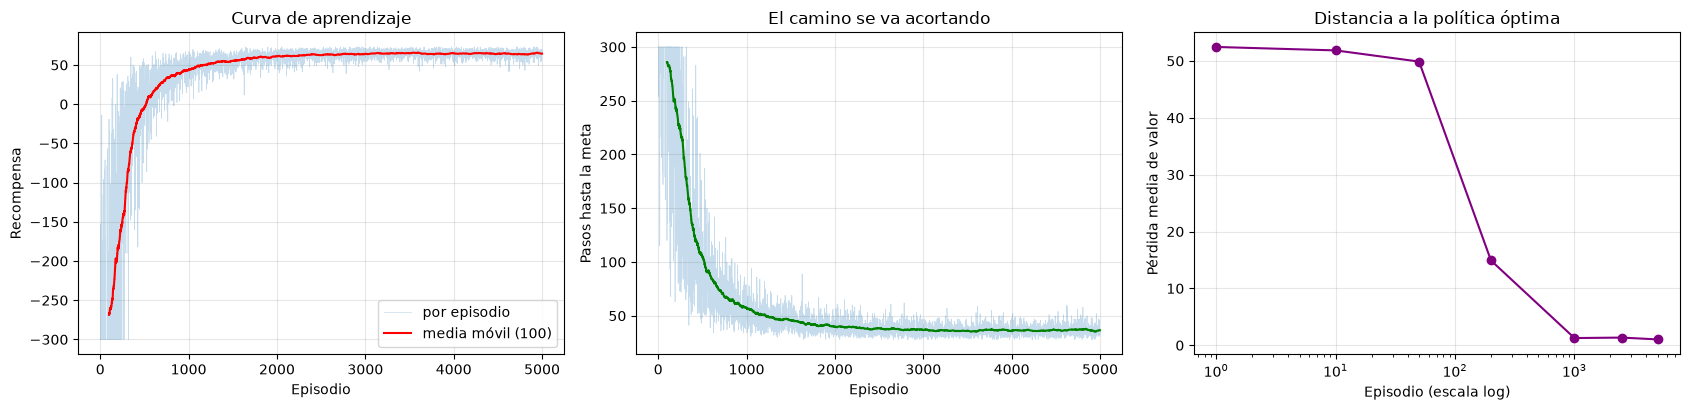

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.2))

# Recompensa por episodio, con media móvil
recompensas = [h["recompensa"] for h in historia_ql]
ventana = 100
media = np.convolve(recompensas, np.ones(ventana) / ventana, mode="valid")
axes[0].plot(recompensas, alpha=0.25, linewidth=0.5, label="por episodio")
axes[0].plot(range(ventana - 1, len(recompensas)), media, color="red",
             label=f"media móvil ({ventana})")
axes[0].set_xlabel("Episodio"); axes[0].set_ylabel("Recompensa")
axes[0].set_title("Curva de aprendizaje"); axes[0].legend(); axes[0].grid(alpha=0.3)

# Pasos por episodio
pasos = [h["pasos"] for h in historia_ql]
media_p = np.convolve(pasos, np.ones(ventana) / ventana, mode="valid")
axes[1].plot(pasos, alpha=0.25, linewidth=0.5)
axes[1].plot(range(ventana - 1, len(pasos)), media_p, color="green")
axes[1].set_xlabel("Episodio"); axes[1].set_ylabel("Pasos hasta la meta")
axes[1].set_title("El camino se va acortando"); axes[1].grid(alpha=0.3)

# Progreso medido contra la política óptima
eps_cp = [p["episodio"] for p in progreso]
axes[2].plot(eps_cp, [p["perdida"] for p in progreso], marker="o", color="purple")
axes[2].set_xscale("log")
axes[2].set_xlabel("Episodio (escala log)")
axes[2].set_ylabel("Pérdida media de valor")
axes[2].set_title("Distancia a la política óptima"); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Cómo se ve la política mientras aprende

El mismo agente en cuatro momentos del entrenamiento. Al principio las flechas apuntan a cualquier lado; después se van alineando hacia la meta.

Un detalle para leer bien la primera imagen: el mapa de calor usa `max_a Q(s,a)`, y en el episodio 1 casi todo el grid sigue en cero porque el agente todavía no lo ha pisado. Ese amarillo uniforme no es "valor alto", es **ausencia de información**. Las pocas celdas oscuras son justamente las que ya visitó y donde aprendió que caminar cuesta.

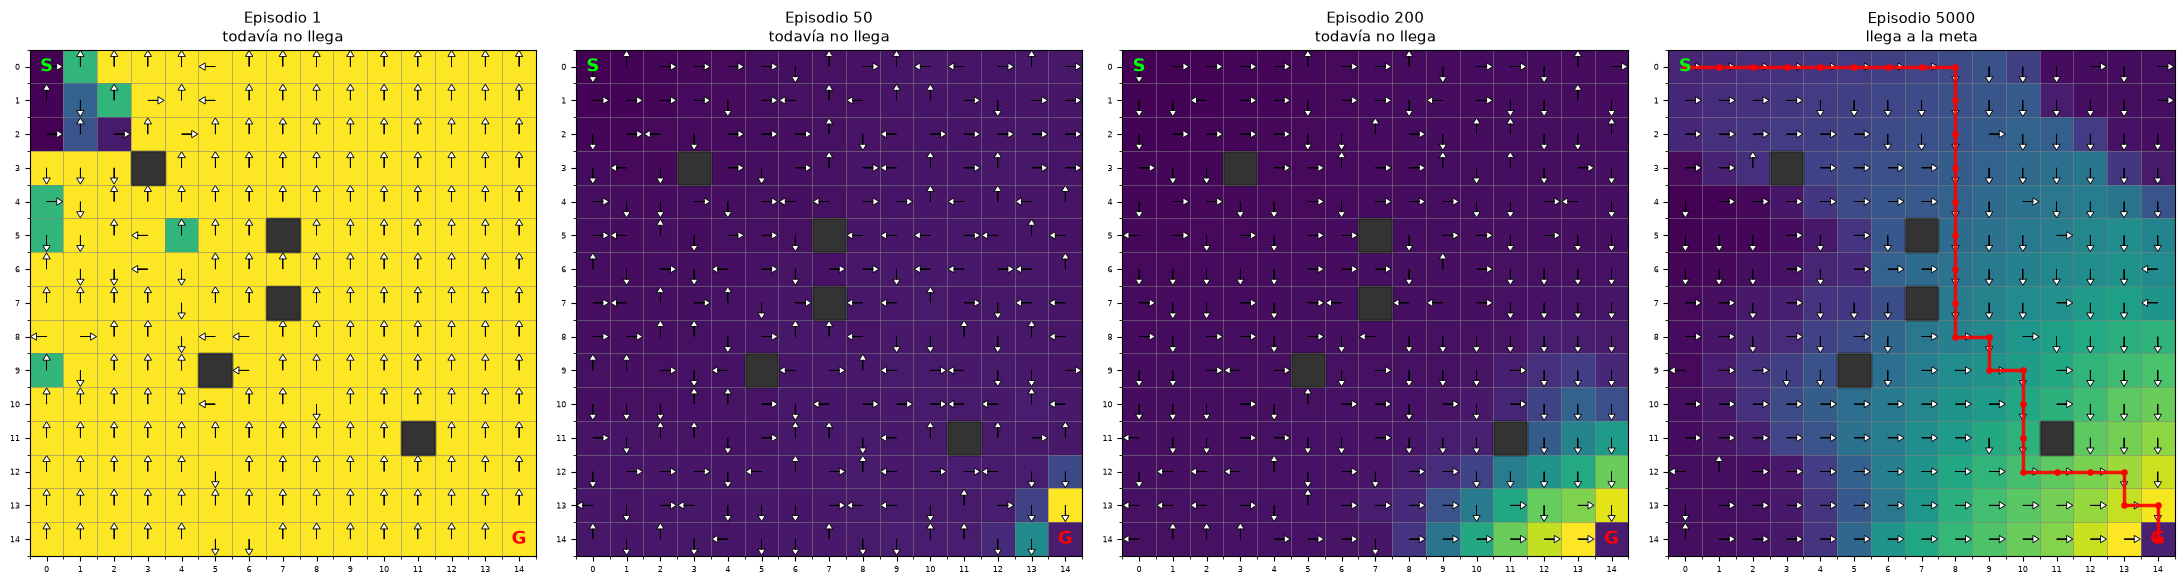

In [14]:
momentos = [1, 50, 200, 5000]
fig, axes = plt.subplots(1, 4, figsize=(22, 5.5))

for ax, cp in zip(axes, momentos):
    Qc = instantaneas_ql[cp]
    pol = politica_greedy(grid, Qc)
    Vc = {s: max(Qc[s].values()) for s in grid.states()}
    ruta_c = camino_intencionado(grid, pol)
    llega = ruta_c[-1] == grid.goal
    dibujar(grid, V=Vc, policy=pol, path=ruta_c if llega else None,
            titulo=f"Episodio {cp}\n{'llega a la meta' if llega else 'todavía no llega'}",
            ax=ax)

plt.tight_layout()
plt.show()

---

## 5. Comparación final

Los tres métodos resolvieron el mismo problema. Ahora los medimos jugando: 300 episodios con cada política, en el mundo estocástico real.

In [15]:
def evaluar(grid, politica, episodios=300, max_steps=300, seed=0):
    rng = random.Random(seed)
    recompensas, longitudes, llegadas = [], [], 0
    for _ in range(episodios):
        s = grid.start
        total = 0.0
        pasos = 0
        for _ in range(max_steps):
            if grid.is_terminal(s):
                llegadas += 1
                break
            s, r, done = grid.step(s, politica[s], rng)
            total += r
            pasos += 1
            if done:
                llegadas += 1
                break
        recompensas.append(total)
        longitudes.append(pasos)
    return (sum(recompensas) / len(recompensas),
            sum(longitudes) / len(longitudes),
            100.0 * llegadas / episodios)


print(f"{'método':>28} | {'recompensa':>11} | {'pasos':>7} | {'llega a la meta':>15}")
print("-" * 72)
for nombre, pol in [("Value Iteration", pi_vi),
                    ("Policy Iteration", pi_pi),
                    ("Q-Learning (5000 episodios)", pi_ql)]:
    r, p, exito = evaluar(grid, pol)
    print(f"{nombre:>28} | {r:>11.2f} | {p:>7.1f} | {exito:>14.1f}%")

print()
print(f"Acciones de Q-Learning que son óptimas: {pct_acciones_optimas(grid, pi_ql):.1f}%")
print(f"Pérdida media de valor:                 {perdida_de_valor(grid, pi_ql, V_vi):.3f}")

                      método |  recompensa |   pasos | llega a la meta
------------------------------------------------------------------------
             Value Iteration |       67.49 |    33.5 |          100.0%
            Policy Iteration |       67.49 |    33.5 |          100.0%
 Q-Learning (5000 episodios) |       67.11 |    33.9 |          100.0%

Acciones de Q-Learning que son óptimas: 74.9%
Pérdida media de valor:                 1.025


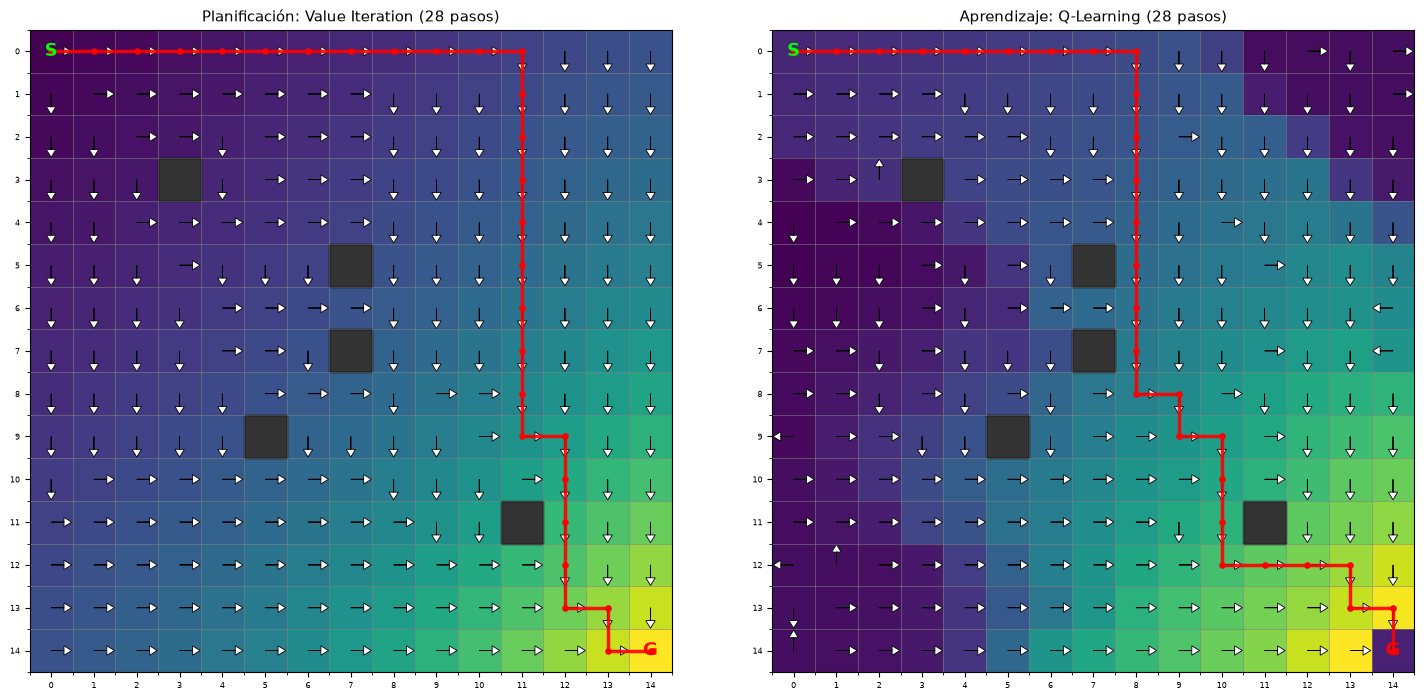

In [16]:
ruta_vi = camino_intencionado(grid, pi_vi)
ruta_ql = camino_intencionado(grid, pi_ql)

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
dibujar(grid, V=V_vi, policy=pi_vi, path=ruta_vi,
        titulo=f"Planificación: Value Iteration ({len(ruta_vi)-1} pasos)", ax=axes[0])
V_ql = {s: max(Q[s].values()) for s in grid.states()}
dibujar(grid, V=V_ql, policy=pi_ql, path=ruta_ql,
        titulo=f"Aprendizaje: Q-Learning ({len(ruta_ql)-1} pasos)", ax=axes[1])
plt.tight_layout()
plt.show()

---

## 6. Conclusiones

**Los dos métodos de planificación coinciden exactamente.** Value Iteration y Policy Iteration llegan a la misma política, con cero estados en desacuerdo. Lo que cambia es cómo llegan: Value Iteration hace muchas iteraciones baratas, cada una con un `max` por estado. Policy Iteration hace pocas iteraciones de política, pero cada una paga una evaluación completa de decenas de barridos. Menos iteraciones no significa menos trabajo.

**El valor se propaga desde la meta hacia atrás.** En las imágenes de las primeras iteraciones se ve que la información nace en la meta y avanza una celda por barrido. Por eso el número de iteraciones que necesita Value Iteration depende del diámetro del grid, no de la cantidad de estados.

**Q-Learning alcanza el mismo desempeño sin conocer el mundo.** Es el resultado más fuerte del ejercicio: la política aprendida obtiene prácticamente la misma recompensa que la calculada con el modelo completo, y el camino tiene esencialmente la misma longitud. El agente nunca leyó `get_transition_probs`, solo caminó y se equivocó.

**Pero coincidir en desempeño no es coincidir en la tabla.** Alrededor de una cuarta parte de las acciones de Q-Learning no son óptimas, y aun así casi no pierde recompensa. La explicación está en dónde ocurren esos errores: en rincones alejados que el agente casi nunca pisa, porque su exploración se concentra en el corredor que une el inicio con la meta. La pérdida de valor promedio es baja, pero en algunos estados remotos es grande.

Ese es el precio de aprender de la experiencia: **solo se aprende bien lo que se visita**. Value Iteration barre todos los estados por igual porque tiene el modelo; Q-Learning invierte su tiempo donde efectivamente camina. Para trazar el mejor camino entre el inicio y el fin eso alcanza y sobra, pero si mañana movieran el punto de partida a una esquina que nunca exploró, la política aprendida ya no sería confiable ahí.

**Sobre el ruido.** Con transiciones deterministas este ejercicio sería un problema de camino más corto y lo resolvería un BFS. El `0.8 / 0.1 / 0.1` es lo que lo convierte en un problema de decisión: la política evita rozar los obstáculos, porque un resbalón contra uno cuesta un paso perdido.